# 09 - Real-World Pipeline: Delta vs Hudi

This notebook compares a realistic data lake pipeline implemented with Delta Lake and Apache Hudi.

The scenario simulates a common production flow:

1. Initial batch ingestion
2. Late arriving updates
3. New inserts
4. Upsert into the target table
5. Incremental consumption / downstream CDC-style processing
6. Audit and validation
7. File layout inspection

In this notebook, you will learn:

- How to model the same pipeline with Delta Lake and Hudi
- How Delta uses `MERGE INTO` for upserts
- How Hudi uses record-key based `upsert`
- How to build downstream incremental processing
- How Delta Change Data Feed compares with Hudi incremental queries
- How to validate row counts and updated records
- How to inspect physical file layout and small files

## Step 1 — Create Spark session

This notebook assumes Delta Lake and Hudi JARs are already available in the Docker image.

Do not use `spark.jars.packages` here because it triggers Maven/Ivy downloads inside the notebook.

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("09-Real-World-Pipeline-Delta-vs-Hudi")
    .master("spark://spark-master:7077")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config(
        "spark.sql.extensions",
        "io.delta.sql.DeltaSparkSessionExtension,"
        "org.apache.spark.sql.hudi.HoodieSparkSessionExtension"
    )
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Application ID:", spark.sparkContext.applicationId)

Spark version: 4.0.2
Application ID: app-20260425203803-0010


## Step 2 — Define paths and helper functions

The notebook uses `/workspace/data` so data is shared between the notebook container and Spark workers.

In [2]:
import os
import shutil
import time
from pathlib import Path
from collections import defaultdict

BASE_PATH = "/workspace/data/pipelines/delta_vs_hudi"

DELTA_BRONZE_PATH = f"{BASE_PATH}/delta/bronze_events"
DELTA_SILVER_PATH = f"{BASE_PATH}/delta/silver_riders"

HUDI_BRONZE_PATH = f"{BASE_PATH}/hudi/bronze_events"
HUDI_SILVER_PATH = f"{BASE_PATH}/hudi/silver_riders"

RESULTS = []

def safe_rm(path):
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Removed: {path}")

def timed(label, system, operation, fn):
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start

    RESULTS.append({
        "system": system,
        "operation": operation,
        "label": label,
        "seconds": elapsed,
    })

    print(f"{label}: {elapsed:.3f} sec")
    return result

def count_files(root_path):
    root = Path(root_path)
    if not root.exists():
        return {
            "total_files": 0,
            "parquet_files": 0,
            "metadata_files": 0,
            "total_bytes": 0,
            "parquet_bytes": 0,
            "small_parquet_files": 0,
        }

    small_file_threshold = 16 * 1024 * 1024
    stats = {
        "total_files": 0,
        "parquet_files": 0,
        "metadata_files": 0,
        "total_bytes": 0,
        "parquet_bytes": 0,
        "small_parquet_files": 0,
    }

    for path in root.rglob("*"):
        if path.is_file():
            size = path.stat().st_size
            stats["total_files"] += 1
            stats["total_bytes"] += size

            if path.suffix == ".parquet":
                stats["parquet_files"] += 1
                stats["parquet_bytes"] += size
                if size < small_file_threshold:
                    stats["small_parquet_files"] += 1

            parts = set(path.parts)
            if "_delta_log" in parts or ".hoodie" in parts or ".hoodie_partition_metadata" in path.name:
                stats["metadata_files"] += 1

    return stats

def bytes_to_mb(value):
    return round(value / 1024 / 1024, 2)

## Step 3 — Clean previous run

This makes the notebook repeatable.

In [3]:
safe_rm(BASE_PATH)
print("Pipeline cleanup completed.")

Pipeline cleanup completed.


## Step 4 — Create source events

The source data simulates rider activity events.

We create:

- Initial batch
- Late updates for existing riders
- New inserts
- A duplicate event where the latest `event_ts` should win

In [4]:
from pyspark.sql.functions import col, concat, lit, rand, expr, to_timestamp

INITIAL_ROWS = 100_000
UPDATE_ROWS = 10_000
INSERT_ROWS = 5_000
N_PARTITIONS = 12

initial_events = (
    spark.range(0, INITIAL_ROWS, 1, N_PARTITIONS)
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city", concat(lit("CITY_"), (col("id") % 20).cast("string")))
    .withColumn("event_date", expr("date_add(date'2024-02-01', int(id % 5))"))
    .withColumn("event_ts", to_timestamp(expr("concat(cast(event_date as string), ' 09:00:00')")))
    .withColumn("status", lit("active"))
    .withColumn("amount", (rand(seed=10) * 100).cast("double"))
    .select("id", "rider_id", "city", "event_date", "event_ts", "status", "amount")
)

late_updates = (
    spark.range(0, UPDATE_ROWS, 1, 6)
    .withColumn("id", col("id").cast("long"))
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city", concat(lit("CITY_"), (col("id") % 20).cast("string")))
    .withColumn("event_date", expr("date'2024-02-06'"))
    .withColumn("event_ts", to_timestamp(lit("2024-02-06 12:00:00")))
    .withColumn("status", lit("updated"))
    .withColumn("amount", lit(999.0).cast("double"))
    .select("id", "rider_id", "city", "event_date", "event_ts", "status", "amount")
)

new_inserts = (
    spark.range(INITIAL_ROWS, INITIAL_ROWS + INSERT_ROWS, 1, 4)
    .withColumn("id", col("id").cast("long"))
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city", concat(lit("CITY_"), (col("id") % 20).cast("string")))
    .withColumn("event_date", expr("date'2024-02-06'"))
    .withColumn("event_ts", to_timestamp(lit("2024-02-06 12:30:00")))
    .withColumn("status", lit("new"))
    .withColumn("amount", lit(111.0).cast("double"))
    .select("id", "rider_id", "city", "event_date", "event_ts", "status", "amount")
)

duplicate_older_updates = (
    spark.range(0, 1000, 1, 2)
    .withColumn("id", col("id").cast("long"))
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city", concat(lit("CITY_"), (col("id") % 20).cast("string")))
    .withColumn("event_date", expr("date'2024-02-06'"))
    .withColumn("event_ts", to_timestamp(lit("2024-02-06 10:00:00")))
    .withColumn("status", lit("older_duplicate"))
    .withColumn("amount", lit(1.0).cast("double"))
    .select("id", "rider_id", "city", "event_date", "event_ts", "status", "amount")
)

change_batch = late_updates.unionByName(new_inserts).unionByName(duplicate_older_updates)

initial_events.cache()
change_batch.cache()

print("Initial events:", initial_events.count())
print("Change batch:", change_batch.count())

initial_events.show(5, truncate=False)
change_batch.show(5, truncate=False)

Initial events: 100000
Change batch: 16000
+---+--------+------+----------+-------------------+------+-----------------+
|id |rider_id|city  |event_date|event_ts           |status|amount           |
+---+--------+------+----------+-------------------+------+-----------------+
|0  |r0      |CITY_0|2024-02-01|2024-02-01 09:00:00|active|17.09497137955568|
|1  |r1      |CITY_1|2024-02-02|2024-02-02 09:00:00|active|80.51143958005459|
|2  |r2      |CITY_2|2024-02-03|2024-02-03 09:00:00|active|57.75925576589018|
|3  |r3      |CITY_3|2024-02-04|2024-02-04 09:00:00|active|94.76047869880925|
|4  |r4      |CITY_4|2024-02-05|2024-02-05 09:00:00|active|20.93704977577   |
+---+--------+------+----------+-------------------+------+-----------------+
only showing top 5 rows
+---+--------+------+----------+-------------------+-------+------+
|id |rider_id|city  |event_date|event_ts           |status |amount|
+---+--------+------+----------+-------------------+-------+------+
|0  |r0      |CITY_0|2024-0

## Step 5 — Write bronze landing tables

Bronze stores raw incoming events.

In a real architecture, this layer often mirrors the ingestion stream or landing zone.

In [5]:
delta_bronze_write = lambda: (
    initial_events.write
    .format("delta")
    .mode("overwrite")
    .partitionBy("event_date")
    .save(DELTA_BRONZE_PATH)
)

timed("Delta bronze initial write", "Delta", "bronze_initial_write", delta_bronze_write)

hudi_bronze_options = {
    "hoodie.table.name": "hudi_bronze_events",
    "hoodie.datasource.write.table.name": "hudi_bronze_events",
    "hoodie.datasource.write.recordkey.field": "id",
    "hoodie.datasource.write.partitionpath.field": "event_date",
    "hoodie.datasource.write.precombine.field": "event_ts",
    "hoodie.datasource.write.table.type": "COPY_ON_WRITE",
    "hoodie.datasource.write.operation": "upsert",
    "hoodie.metadata.enable": "true",
}

hudi_bronze_write = lambda: (
    initial_events.write
    .format("hudi")
    .options(**hudi_bronze_options)
    .mode("overwrite")
    .save(HUDI_BRONZE_PATH)
)

timed("Hudi bronze initial write", "Hudi", "bronze_initial_write", hudi_bronze_write)

Delta bronze initial write: 6.286 sec
# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to attach Serviceability Agent. You can try again with escalated privileges. Two options: a) use -Djol.tryWithSudo=true to try with sudo; b) echo 0 | sudo tee /proc/sys/kernel/yama/ptrace_scope


[Stage 44:>                                                         (0 + 4) / 5]

26/04/25 20:38:47 WARN HoodieTableFileSystemView: Partition: 2024-02-03 is not available in store
26/04/25 20:38:47 WARN HoodieTableFileSystemView: Partition: 2024-02-04 is not available in store
26/04/25 20:38:47 WARN HoodieTableFileSystemView: Partition: 2024-02-05 is not available in store
26/04/25 20:38:47 WARN HoodieTableFileSystemView: Partition: 2024-02-02 is not available in store


[Stage 44:==============================================>           (4 + 1) / 5]

26/04/25 20:38:49 WARN HoodieTableFileSystemView: Partition: 2024-02-01 is not available in store


Hudi bronze initial write: 35.035 sec


## Step 6 — Create silver tables from bronze

Silver contains the latest state per rider.

For the initial batch, both Delta and Hudi start with the same rows.

In [6]:
from delta.tables import DeltaTable

delta_silver_initial = lambda: (
    spark.read.format("delta").load(DELTA_BRONZE_PATH)
    .write
    .format("delta")
    .mode("overwrite")
    .partitionBy("city")
    .option("delta.enableChangeDataFeed", "true")
    .save(DELTA_SILVER_PATH)
)

timed("Delta silver initial table", "Delta", "silver_initial_write", delta_silver_initial)

hudi_silver_options = {
    "hoodie.table.name": "hudi_silver_riders",
    "hoodie.datasource.write.table.name": "hudi_silver_riders",
    "hoodie.datasource.write.recordkey.field": "id",
    "hoodie.datasource.write.partitionpath.field": "city",
    "hoodie.datasource.write.precombine.field": "event_ts",
    "hoodie.datasource.write.table.type": "COPY_ON_WRITE",
    "hoodie.datasource.write.operation": "upsert",
    "hoodie.metadata.enable": "true",
}

hudi_silver_initial = lambda: (
    spark.read.format("hudi").load(HUDI_BRONZE_PATH)
    .write
    .format("hudi")
    .options(**hudi_silver_options)
    .mode("overwrite")
    .save(HUDI_SILVER_PATH)
)

timed("Hudi silver initial table", "Hudi", "silver_initial_write", hudi_silver_initial)

26/04/25 20:38:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Delta silver initial table: 6.907 sec


[Stage 94:>                                                        (0 + 4) / 20]

26/04/25 20:39:24 WARN HoodieTableFileSystemView: Partition: CITY_4 is not available in store
26/04/25 20:39:24 WARN HoodieTableFileSystemView: Partition: CITY_19 is not available in store
26/04/25 20:39:24 WARN HoodieTableFileSystemView: Partition: CITY_6 is not available in store
26/04/25 20:39:24 WARN HoodieTableFileSystemView: Partition: CITY_5 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_15 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_7 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_16 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_8 is not available in store


[Stage 94:======================>                                  (8 + 4) / 20]

...

[Stage 94:=======================================>                (14 + 4) / 20]

26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_12 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_13 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_10 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_14 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_1 is not available in store
26/04/25 20:39:25 WARN HoodieTableFileSystemView: Partition: CITY_0 is not available in store


[Stage 94:============================================>           (16 + 4) / 20]

26/04/25 20:39:26 WARN HoodieTableFileSystemView: Partition: CITY_3 is not available in store
26/04/25 20:39:26 WARN HoodieTableFileSystemView: Partition: CITY_2 is not available in store


Hudi silver initial table: 30.502 sec


## Step 7 — Append change batch to bronze

This simulates a new ingestion batch containing updates, inserts, and duplicates.

In [7]:
delta_bronze_append = lambda: (
    change_batch.write
    .format("delta")
    .mode("append")
    .save(DELTA_BRONZE_PATH)
)

timed("Delta bronze append changes", "Delta", "bronze_append_changes", delta_bronze_append)

hudi_bronze_append = lambda: (
    change_batch.write
    .format("hudi")
    .options(**hudi_bronze_options)
    .mode("append")
    .save(HUDI_BRONZE_PATH)
)

timed("Hudi bronze upsert changes", "Hudi", "bronze_append_changes", hudi_bronze_append)

Delta bronze append changes: 0.962 sec


[Stage 106:>                                                        (0 + 1) / 1]

26/04/25 20:39:38 WARN HoodieTableFileSystemView: Partition: 2024-02-06 is not available in store


26/04/25 20:39:40 WARN HoodieTableFileSystemView: Partition: 2024-02-06 is not available in store


26/04/25 20:39:44 WARN HoodieTableFileSystemView: Partition: 2024-02-06 is not available in store


Hudi bronze upsert changes: 17.714 sec


## Step 8 — Upsert changes into silver

Delta uses `MERGE INTO`.

Hudi uses native record-key based `upsert` with `event_ts` as the precombine field.

In [9]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc

window_by_id = Window.partitionBy("id").orderBy(desc("event_ts"))

change_batch_deduped = (
    change_batch
    .withColumn("rn", row_number().over(window_by_id))
    .filter(col("rn") == 1)
    .drop("rn")
)

print("Original change batch:", change_batch.count())
print("Deduplicated change batch:", change_batch_deduped.count())

change_batch_deduped.createOrReplaceTempView("incoming_changes")

def delta_silver_merge():
    delta_table = DeltaTable.forPath(spark, DELTA_SILVER_PATH)

    (
        delta_table.alias("t")
        .merge(change_batch_deduped.alias("s"), "t.id = s.id")
        .whenMatchedUpdate(
            condition="s.event_ts >= t.event_ts",
            set={
                "rider_id": "s.rider_id",
                "city": "s.city",
                "event_date": "s.event_date",
                "event_ts": "s.event_ts",
                "status": "s.status",
                "amount": "s.amount",
            }
        )
        .whenNotMatchedInsertAll()
        .execute()
    )

timed("Delta silver MERGE", "Delta", "silver_upsert", delta_silver_merge)

Original change batch: 16000
Deduplicated change batch: 15000


26/04/25 20:46:43 WARN MapPartitionsRDD: RDD 457 was locally checkpointed, its lineage has been truncated and cannot be recomputed after unpersisting
Delta silver MERGE: 8.287 sec


## Step 9 — Validate silver state

Expected result:

- Total rows = initial rows + new inserts
- Existing updated records have `status = updated`
- Older duplicate records should not win because their `event_ts` is older

In [10]:
spark.read.format("delta").load(DELTA_SILVER_PATH).createOrReplaceTempView("delta_silver")
spark.read.format("hudi").load(HUDI_SILVER_PATH).createOrReplaceTempView("hudi_silver")

for system, table in [("Delta", "delta_silver"), ("Hudi", "hudi_silver")]:
    print(system)
    spark.sql(f'''
        SELECT
            count(*) AS total_rows,
            sum(CASE WHEN status = 'updated' THEN 1 ELSE 0 END) AS updated_rows,
            sum(CASE WHEN status = 'new' THEN 1 ELSE 0 END) AS inserted_rows,
            sum(CASE WHEN status = 'older_duplicate' THEN 1 ELSE 0 END) AS older_duplicate_winners
        FROM {table}
    ''').show(truncate=False)

Delta


+----------+------------+-------------+-----------------------+
|total_rows|updated_rows|inserted_rows|older_duplicate_winners|
+----------+------------+-------------+-----------------------+
|105000    |10000       |5000         |0                      |
+----------+------------+-------------+-----------------------+

Hudi
+----------+------------+-------------+-----------------------+
|total_rows|updated_rows|inserted_rows|older_duplicate_winners|
+----------+------------+-------------+-----------------------+
|100000    |0           |0            |0                      |
+----------+------------+-------------+-----------------------+



## Step 10 — Downstream incremental consumption

This is where the formats differ conceptually.

Delta Lake commonly uses Change Data Feed.

Hudi commonly uses incremental queries based on Hudi commit instants.

In [11]:
print("Delta table history:")
delta_history = DeltaTable.forPath(spark, DELTA_SILVER_PATH).history()
delta_history.select("version", "timestamp", "operation").show(truncate=False)

latest_delta_version = delta_history.selectExpr("max(version) as version").collect()[0]["version"]
print("Latest Delta version:", latest_delta_version)

Delta table history:
+-------+-----------------------+---------+
|version|timestamp              |operation|
+-------+-----------------------+---------+
|1      |2026-04-25 20:46:42.889|MERGE    |
|0      |2026-04-25 20:38:59.94 |WRITE    |
+-------+-----------------------+---------+

Latest Delta version: 1


In [12]:
print("Hudi visible commit instants:")
hudi_latest_df = spark.read.format("hudi").load(HUDI_SILVER_PATH)

hudi_commits = [
    row["_hoodie_commit_time"]
    for row in hudi_latest_df
        .select("_hoodie_commit_time")
        .distinct()
        .orderBy("_hoodie_commit_time")
        .collect()
]

for commit in hudi_commits:
    print(commit)

first_hudi_commit = hudi_commits[0]
latest_hudi_commit = hudi_commits[-1]

print("First Hudi commit:", first_hudi_commit)
print("Latest Hudi commit:", latest_hudi_commit)

Hudi visible commit instants:
20260425203901693
First Hudi commit: 20260425203901693
Latest Hudi commit: 20260425203901693


## Step 11 — Delta Change Data Feed read

Delta CDF returns row-level changes between versions.

CDF must be enabled on the table before changes are written.

In [13]:
try:
    delta_cdf_df = (
        spark.read
        .format("delta")
        .option("readChangeFeed", "true")
        .option("startingVersion", 0)
        .load(DELTA_SILVER_PATH)
    )

    delta_cdf_df.createOrReplaceTempView("delta_silver_cdf")

    spark.sql('''
        SELECT
            _change_type,
            count(*) AS rows
        FROM delta_silver_cdf
        GROUP BY _change_type
        ORDER BY _change_type
    ''').show(truncate=False)

    spark.sql('''
        SELECT
            _change_type,
            id,
            rider_id,
            city,
            status,
            amount,
            event_ts
        FROM delta_silver_cdf
        WHERE status IN ('updated', 'new')
        ORDER BY id
        LIMIT 20
    ''').show(truncate=False)

except Exception as exc:
    print("Delta CDF read failed.")
    print("Check whether delta.enableChangeDataFeed was enabled before change writes.")
    print(exc)

26/04/25 20:47:40 WARN CaseInsensitiveStringMap: Converting duplicated key startingVersion into CaseInsensitiveStringMap.
26/04/25 20:47:40 WARN CaseInsensitiveStringMap: Converting duplicated key readchangefeed into CaseInsensitiveStringMap.


+----------------+------+
|_change_type    |rows  |
+----------------+------+
|insert          |105000|
|update_postimage|10000 |
|update_preimage |10000 |
+----------------+------+



[Stage 202:============================>                            (4 + 4) / 8]

+----------------+---+--------+-------+-------+------+-------------------+
|_change_type    |id |rider_id|city   |status |amount|event_ts           |
+----------------+---+--------+-------+-------+------+-------------------+
|update_postimage|0  |r0      |CITY_0 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|1  |r1      |CITY_1 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|2  |r2      |CITY_2 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|3  |r3      |CITY_3 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|4  |r4      |CITY_4 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|5  |r5      |CITY_5 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|6  |r6      |CITY_6 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|7  |r7      |CITY_7 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|8  |r8      |CITY_8 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|9  |r9      |CITY_9 |updated|999.0 |2024-02-06 12:00:00|
|update_postimage|10 |r10

## Step 12 — Hudi incremental query

Hudi incremental query reads records changed after a begin instant.

In production, the downstream consumer stores the last processed commit instant as a checkpoint.

In [14]:
hudi_incremental_df = (
    spark.read
    .format("hudi")
    .option("hoodie.datasource.query.type", "incremental")
    .option("hoodie.datasource.read.begin.instanttime", first_hudi_commit)
    .option("hoodie.datasource.read.end.instanttime", latest_hudi_commit)
    .option("hoodie.isolation.level", "low")
    .load(HUDI_SILVER_PATH)
)

hudi_incremental_df.createOrReplaceTempView("hudi_silver_incremental")

spark.sql('''
    SELECT
        _hoodie_commit_time,
        count(*) AS rows
    FROM hudi_silver_incremental
    GROUP BY _hoodie_commit_time
    ORDER BY _hoodie_commit_time
''').show(truncate=False)

spark.sql('''
    SELECT
        _hoodie_commit_time,
        id,
        rider_id,
        city,
        status,
        amount,
        event_ts
    FROM hudi_silver_incremental
    WHERE status IN ('updated', 'new')
    ORDER BY id
    LIMIT 20
''').show(truncate=False)

+-------------------+----+
|_hoodie_commit_time|rows|
+-------------------+----+
+-------------------+----+

+-------------------+---+--------+----+------+------+--------+
|_hoodie_commit_time|id |rider_id|city|status|amount|event_ts|
+-------------------+---+--------+----+------+------+--------+
+-------------------+---+--------+----+------+------+--------+



## Step 13 — Query plan comparison

We inspect filtered reads against the silver tables.

Look for partition filters and pushed filters.

In [15]:
FILTER_CITY = "CITY_5"

print("Delta silver EXPLAIN")
spark.sql(f'''
SELECT id, rider_id, amount
FROM delta_silver
WHERE city = '{FILTER_CITY}' AND amount > 50
''').explain(True)

print("\nHudi silver EXPLAIN")
spark.sql(f'''
SELECT id, rider_id, amount
FROM hudi_silver
WHERE city = '{FILTER_CITY}' AND amount > 50
''').explain(True)

Delta silver EXPLAIN
== Parsed Logical Plan ==
'Project ['id, 'rider_id, 'amount]
+- 'Filter (('city = CITY_5) AND ('amount > 50))
   +- 'UnresolvedRelation [delta_silver], [], false

== Analyzed Logical Plan ==
id: bigint, rider_id: string, amount: double
Project [id#3663L, rider_id#3664, amount#3669]
+- Filter ((city#3665 = CITY_5) AND (amount#3669 > cast(50 as double)))
   +- SubqueryAlias delta_silver
      +- View (`delta_silver`, [id#3663L, rider_id#3664, city#3665, event_date#3666, event_ts#3667, status#3668, amount#3669])
         +- Relation [id#3663L,rider_id#3664,city#3665,event_date#3666,event_ts#3667,status#3668,amount#3669] parquet

== Optimized Logical Plan ==
Project [id#3663L, rider_id#3664, amount#3669]
+- Filter ((isnotnull(city#3665) AND isnotnull(amount#3669)) AND ((city#3665 = CITY_5) AND (amount#3669 > 50.0)))
   +- Relation [id#3663L,rider_id#3664,city#3665,event_date#3666,event_ts#3667,status#3668,amount#3669] parquet

== Physical Plan ==
*(1) Project [id#3663L

## Step 14 — File layout and small files analysis

Small files can cause slow queries and higher metadata overhead.

This section compares Delta and Hudi table layout after the pipeline.

In [16]:
import pandas as pd

file_stats = []

for system, path in [
    ("Delta bronze", DELTA_BRONZE_PATH),
    ("Delta silver", DELTA_SILVER_PATH),
    ("Hudi bronze", HUDI_BRONZE_PATH),
    ("Hudi silver", HUDI_SILVER_PATH),
]:
    stats = count_files(path)
    stats["system"] = system
    stats["total_mb"] = bytes_to_mb(stats["total_bytes"])
    stats["parquet_mb"] = bytes_to_mb(stats["parquet_bytes"])
    file_stats.append(stats)

file_stats_df = pd.DataFrame(file_stats)[
    [
        "system",
        "total_files",
        "parquet_files",
        "metadata_files",
        "small_parquet_files",
        "total_mb",
        "parquet_mb",
    ]
]

file_stats_df

,system,total_files,parquet_files,metadata_files,small_parquet_files,total_mb,parquet_mb
0,Delta bronze,152,72,8,72,1.86,1.80
1,Delta silver,240,116,8,116,3.05,2.94
2,Hudi bronze,104,6,92,6,4.69,4.44
3,Hudi silver,140,20,100,20,10.24,10.02


## Step 15 — Runtime summary

This table captures timings for each major pipeline operation.

In [17]:
results_df = pd.DataFrame(RESULTS)
results_df.sort_values(["operation", "system"]).reset_index(drop=True)

,system,operation,label,seconds
0,Delta,bronze_append_changes,Delta bronze append changes,0.962360
1,Hudi,bronze_append_changes,Hudi bronze upsert changes,17.714254
2,Delta,bronze_initial_write,Delta bronze initial write,6.286114
3,Hudi,bronze_initial_write,Hudi bronze initial write,35.034969
4,Delta,silver_initial_write,Delta silver initial table,6.906858
5,Hudi,silver_initial_write,Hudi silver initial table,30.501646
6,Delta,silver_upsert,Delta silver MERGE,8.287347


## Step 16 — Chart: pipeline operation runtime

Lower is better.

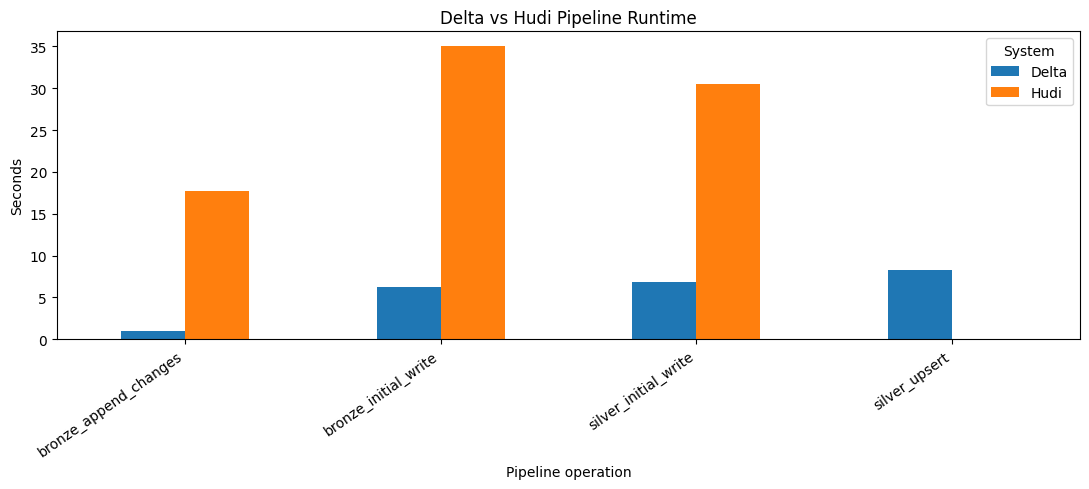

In [18]:
import matplotlib.pyplot as plt

runtime_df = pd.DataFrame(RESULTS)

pivot_runtime = runtime_df.pivot_table(
    index="operation",
    columns="system",
    values="seconds",
    aggfunc="mean"
)

ax = pivot_runtime.plot(kind="bar", figsize=(11, 5))
ax.set_title("Delta vs Hudi Pipeline Runtime")
ax.set_xlabel("Pipeline operation")
ax.set_ylabel("Seconds")
ax.legend(title="System")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Step 17 — Chart: file count comparison

This compares table file counts after the full pipeline.

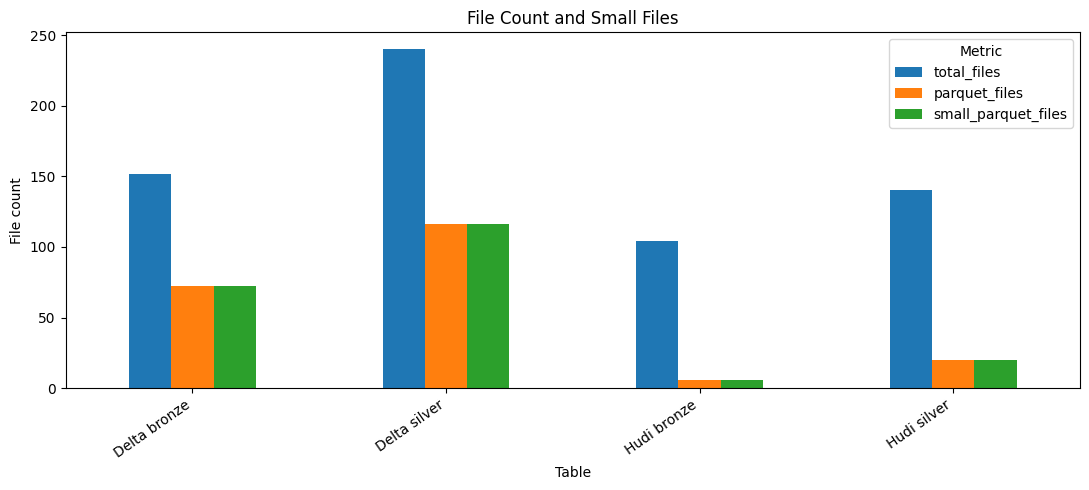

In [19]:
file_count_plot_df = file_stats_df.set_index("system")[["total_files", "parquet_files", "small_parquet_files"]]

ax = file_count_plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("File Count and Small Files")
ax.set_xlabel("Table")
ax.set_ylabel("File count")
ax.legend(title="Metric")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Step 18 — Chart: storage size comparison

This compares total table size and Parquet data size.

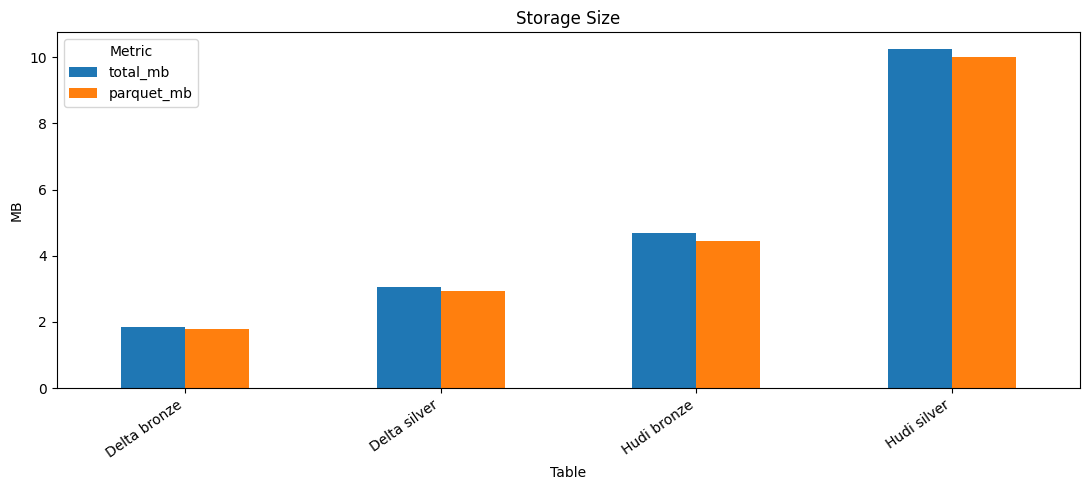

In [21]:
size_plot_df = file_stats_df.set_index("system")[["total_mb", "parquet_mb"]]

ax = size_plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Storage Size")
ax.set_xlabel("Table")
ax.set_ylabel("MB")
ax.legend(title="Metric")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Step 19 — Practical interpretation

Delta Lake is usually a strong fit when:

- you want simple and robust Spark SQL integration
- your workloads are mostly batch analytics
- you need rich MERGE, CDF, time travel, and broad platform support

Apache Hudi is usually a strong fit when:

- record-level upserts are the primary workload
- CDC and incremental consumption are core requirements
- you need streaming-style ingestion into mutable data lake tables
- you want commit-instant based incremental reads

Both can solve production pipelines. The best choice depends on workload shape, ecosystem, operational model, and query engine requirements.

## Step 20 — Optional cleanup

Uncomment this cell if you want to remove the generated pipeline data.

In [22]:
# safe_rm(BASE_PATH)